In [5]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Parametre ---
SEQUENCE_LENGTH = 99
BATCH_SIZE = 512
EPOCHS = 5
TRAIN_FILES = [
    f"standardized_house1_{i}.csv" for i in range(6)
]
TEST_FILE = "standardized_house1_6.csv"

# --- Pomocné funkcie ---
def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

def normalize(data, mean, std):
    return (data - mean) / std

def denormalize(data, mean, std):
    return data * std + mean

def load_data(file, appliance):
    df = pd.read_csv(file, index_col=0, parse_dates=True)
    return df["main"].values, df[appliance].values

def build_model(sequence_length):
    model = Sequential()
    model.add(Conv1D(30, 10, activation="relu", input_shape=(sequence_length, 1), strides=2))
    model.add(Conv1D(30, 8, activation='relu', strides=2))
    model.add(Conv1D(40, 6, activation='relu', strides=1))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(.2))
    model.add(Dense(sequence_length))
    model.compile(optimizer='adam', loss='mse')
    return model

# --- Zistenie zoznamu spotrebičov ---
sample_df = pd.read_csv(TRAIN_FILES[0], index_col=0, parse_dates=True)
appliance_list = [col for col in sample_df.columns if col not in ['main', 'timestamp', 'Unnamed: 0']]

# --- Trénovanie a testovanie pre každý spotrebič ---
results = []

for appliance in appliance_list:
    print(f"\n➡ Spracovanie spotrebiča: {appliance}")

    train_main_all, train_app_all = [], []
    for f in TRAIN_FILES[:-1]:  # house1_0 až house1_5
        main, app = load_data(f, appliance)
        train_main_all.append(main)
        train_app_all.append(app)

    train_main = np.concatenate(train_main_all)
    train_app = np.concatenate(train_app_all)

    main_mean, main_std = np.mean(train_main), np.std(train_main)
    app_mean, app_std = np.mean(train_app), np.std(train_app)

    main_seq = create_sequences(normalize(train_main, main_mean, main_std), SEQUENCE_LENGTH)
    app_seq = create_sequences(normalize(train_app, app_mean, app_std), SEQUENCE_LENGTH)

    min_len = min(len(main_seq), len(app_seq))
    train_main_seq = main_seq[:min_len].reshape((-1, SEQUENCE_LENGTH, 1))
    train_app_seq = app_seq[:min_len]

    model = build_model(SEQUENCE_LENGTH)
    checkpoint_path = f"seq2seq-{appliance}-best.h5"
    checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, mode="min", verbose=0)          
    model.fit(train_main_seq, train_app_seq, epochs=EPOCHS, batch_size=BATCH_SIZE,  
              validation_split=0.15, callbacks=[checkpoint], verbose=0)
    model.load_weights(checkpoint_path)

    test_main, test_app = load_data(TEST_FILE, appliance)
    test_main_norm = normalize(test_main, main_mean, main_std)
    test_seq = create_sequences(test_main_norm, SEQUENCE_LENGTH).reshape((-1, SEQUENCE_LENGTH, 1))
    pred_seq = model.predict(test_seq, verbose=0)

/tmp/ipykernel_132/2745171649.py:49: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sample_df = pd.read_csv(TRAIN_FILES[0], index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To en


➡ Spracovanie spotrebiča: electric space heater


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-17 09:42:08.467792: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)



➡ Spracovanie spotrebiča: electric stove


/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is c

...


➡ Spracovanie spotrebiča: microwave


/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is c


➡ Spracovanie spotrebiča: washer dryer


/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file, index_col=0, parse_dates=True)
/tmp/ipykernel_132/2745171649.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is c


📊 Výsledky Seq2Seq modelu na REDD (po spotrebičoch):
               Spotrebič  MAE (W)   MSE (W²)  RMSE (W)
0  electric space heater     0.31       1.65      1.28
1         electric stove     0.26       1.06      1.03
2                 fridge    74.87   11920.36    109.18
3              microwave    45.25   38044.24    195.05
4           washer dryer   114.34  206251.61    454.15


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Parametre ---
SEQUENCE_LENGTH = 99
SAMPLE_INTERVAL_SECONDS = 5
SAMPLES_PER_15_MIN = int(15 * 60 / SAMPLE_INTERVAL_SECONDS)
BATCH_SIZE = 512
EPOCHS = 5
TRAIN_FILES = [f"standardized_house1_{i}.csv" for i in range(6)]
TEST_FILE = "standardized_house1_6.csv"

# --- Pomocné funkcie ---
def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

def normalize(data, mean, std):
    return (data - mean) / std

def denormalize(data, mean, std):
    return data * std + mean

def load_data(file, appliance):
    df = pd.read_csv(file)
    return df["main"].values, df[appliance].values

def build_model(sequence_length):
    model = Sequential()
    model.add(Conv1D(30, 10, activation="relu", input_shape=(sequence_length, 1), strides=2))
    model.add(Conv1D(30, 8, activation='relu', strides=2))
    model.add(Conv1D(40, 6, activation='relu', strides=1))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(.2))
    model.add(Dense(sequence_length))
    model.compile(optimizer='adam', loss='mse')
    return model

# --- Zoznam spotrebičov ---
sample_df = pd.read_csv(TRAIN_FILES[0])
appliance_list = [col for col in sample_df.columns if col not in ['main', 'timestamp', 'Unnamed: 0']]

# --- Uchovávanie všetkých predikcií a skutočných hodnôt ---
y_true_all = []
y_pred_all = []

# --- Trénovanie a testovanie pre každý spotrebič ---
for appliance in appliance_list:
    print(f"\n➡ Spracovanie spotrebiča: {appliance}")

    # Tréningové dáta
    train_main_all, train_app_all = [], []
    for f in TRAIN_FILES[:-1]:  # house1_0 až house1_5
        main, app = load_data(f, appliance)
        train_main_all.append(main)
        train_app_all.append(app)
    train_main = np.concatenate(train_main_all)
    train_app = np.concatenate(train_app_all)

    # Normalizácia a tvorba sekvencií
    main_mean, main_std = np.mean(train_main), np.std(train_main)
    app_mean, app_std = np.mean(train_app), np.std(train_app)

    main_seq = create_sequences(normalize(train_main, main_mean, main_std), SEQUENCE_LENGTH)
    app_seq = create_sequences(normalize(train_app, app_mean, app_std), SEQUENCE_LENGTH)

    min_len = min(len(main_seq), len(app_seq))
    train_main_seq = main_seq[:min_len].reshape((-1, SEQUENCE_LENGTH, 1))
    train_app_seq = app_seq[:min_len]

    # Trénovanie modelu
    model = build_model(SEQUENCE_LENGTH)
    model.fit(train_main_seq, train_app_seq, epochs=EPOCHS, batch_size=BATCH_SIZE,
              validation_split=0.15, verbose=0)

    # Testovacie dáta
    test_main, test_app = load_data(TEST_FILE, appliance)
    test_main_norm = normalize(test_main, main_mean, main_std)
    test_seq = create_sequences(test_main_norm, SEQUENCE_LENGTH).reshape((-1, SEQUENCE_LENGTH, 1))
    pred_seq = model.predict(test_seq, verbose=0)

    # Prekrytie výstupov
    n = len(pred_seq) + SEQUENCE_LENGTH - 1
    sum_arr = np.zeros(n)
    count_arr = np.zeros(n)
    for i in range(len(pred_seq)):
        sum_arr[i:i + SEQUENCE_LENGTH] += pred_seq[i]
        count_arr[i:i + SEQUENCE_LENGTH] += 1
    pred_avg = sum_arr / count_arr
    pred_final = np.maximum(denormalize(pred_avg, app_mean, app_std), 0)

    # Výrez a uloženie do celkových metrík
    aligned_len = min(len(test_app), len(pred_final))
    end_index = min(SAMPLES_PER_15_MIN, aligned_len)

    y_true_all.extend(test_app[:aligned_len])
    y_pred_all.extend(pred_final[:aligned_len])


# --- Celkové metriky pre všetky spotrebiče spolu ---
mae_total = mean_absolute_error(y_true_all, y_pred_all)
mse_total = mean_squared_error(y_true_all, y_pred_all)
rmse_total = np.sqrt(mse_total)

print("\n Celkové metriky Seq2Seq modelu pre všetky spotrebiče:")                 
print(f"MAE:  {mae_total:.2f} W")
print(f"MSE:  {mse_total:.2f} W²")
print(f"RMSE: {rmse_total:.2f} W")


➡ Spracovanie spotrebiča: dish washer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



➡ Spracovanie spotrebiča: electric space heater


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



➡ Spracovanie spotrebiča: electric stove


...


➡ Spracovanie spotrebiča: microwave


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



➡ Spracovanie spotrebiča: washer dryer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 Celkové metriky Seq2Seq modelu pre všetky spotrebiče:
MAE:  51.03 W
MSE:  51497.74 W²
RMSE: 226.93 W


➡ Spracovanie: dish washer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: electric space heater


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: electric stove


...

➡ Spracovanie: microwave


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: washer dryer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 Výsledky Seq2Seq na REDD (časovo zarovnané):
               Spotrebič  MAE (W)   MSE (W²)  RMSE (W)
0            dish washer    89.60   59964.16    244.88
1  electric space heater     0.24       1.39      1.18
2         electric stove     0.20       0.84      0.92
3                 fridge    61.26    9811.88     99.05
4              microwave    33.28   28645.58    169.25
5           washer dryer   203.48  224419.70    473.73


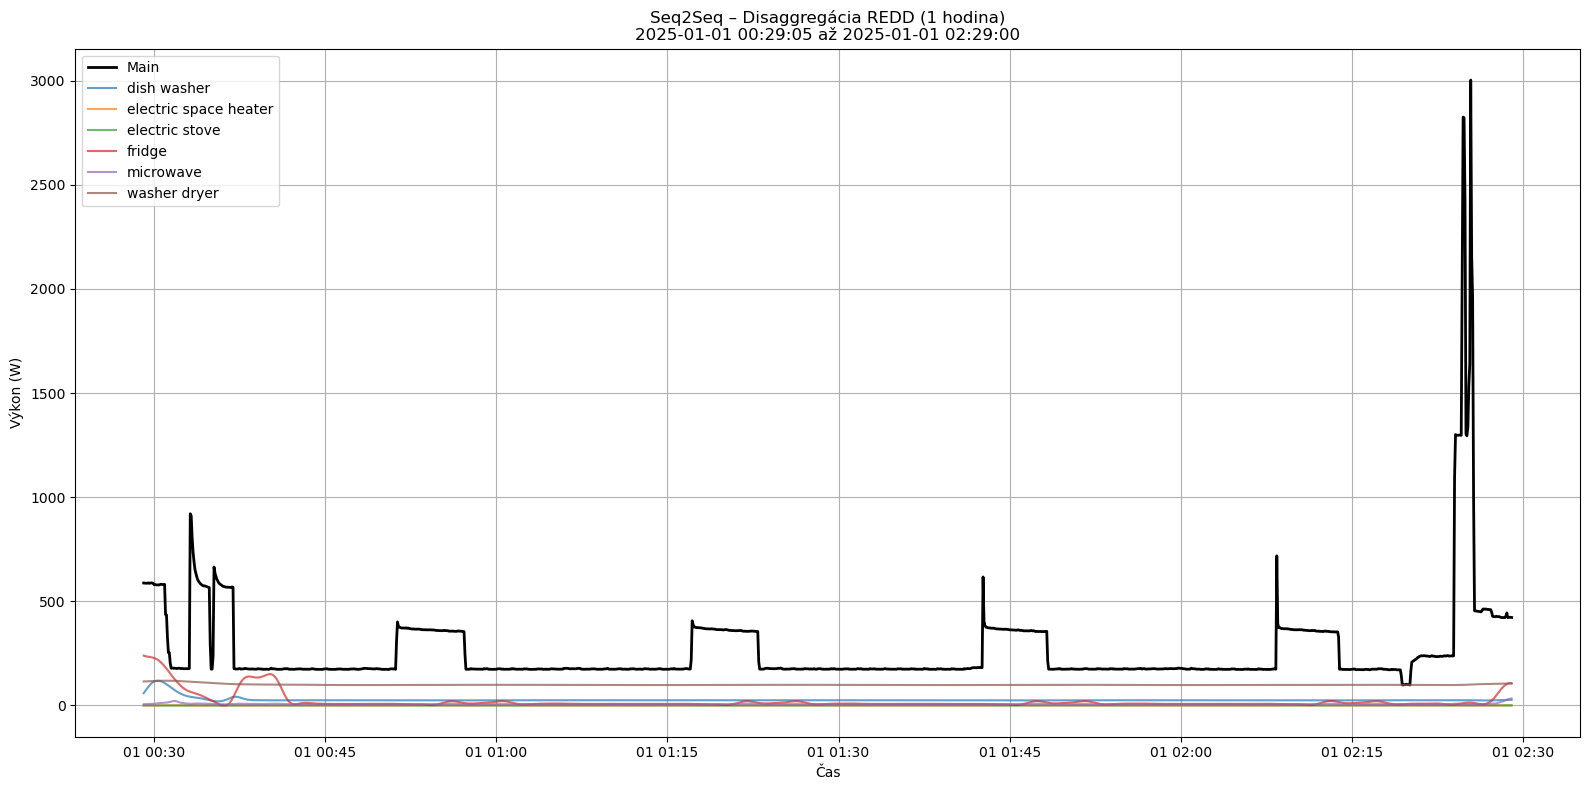

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Parametre ---
SEQUENCE_LENGTH = 99
PRED_SHIFT = SEQUENCE_LENGTH // 2
TEST_FILE = "standardized_house1_6.csv"
SAMPLES_PER_HOUR = 2 * 60 * 60 // 5  # 1 hodina
start = 300
end = start + SAMPLES_PER_HOUR

# --- Pomocné funkcie ---
def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

def normalize(data, mean, std):
    return (data - mean) / std

def denormalize(data, mean, std):
    return data * std + mean

def build_model():
    model = Sequential()
    model.add(Conv1D(30, 10, activation="relu", input_shape=(SEQUENCE_LENGTH, 1), strides=2))
    model.add(Conv1D(30, 8, activation='relu', strides=2))
    model.add(Conv1D(40, 6, activation='relu', strides=1))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(.2))
    model.add(Dense(SEQUENCE_LENGTH))
    model.compile(optimizer='adam', loss='mse')
    return model

# --- Načítanie dát ---
df = pd.read_csv(TEST_FILE)
timestamp = pd.to_datetime(df["timestamp"])
main = df["main"].values
appliance_list = [col for col in df.columns if col not in ['main', 'timestamp', 'Unnamed: 0']]

# --- Výpočty ---
results = []
predictions_dict = {}
timestamps_aligned = timestamp.iloc[PRED_SHIFT:len(main)].reset_index(drop=True)

for appliance in appliance_list:
    try:
        print(f"➡ Spracovanie: {appliance}")
        true = df[appliance].values

        # Normalizácia
        main_mean, main_std = np.mean(main), np.std(main)
        app_mean, app_std = np.mean(true), np.std(true)
        main_norm = normalize(main, main_mean, main_std)

        test_seq = create_sequences(main_norm, SEQUENCE_LENGTH).reshape((-1, SEQUENCE_LENGTH, 1))

        # Model a predikcia
        model = build_model()
        model.load_weights(f"seq2seq-{appliance}-best.h5")
        pred_seq = model.predict(test_seq, verbose=0)

        n = len(pred_seq) + SEQUENCE_LENGTH - 1
        sum_arr = np.zeros(n)
        count_arr = np.zeros(n)
        for i in range(len(pred_seq)):
            sum_arr[i:i + SEQUENCE_LENGTH] += pred_seq[i]
            count_arr[i:i + SEQUENCE_LENGTH] += 1
        pred_avg = sum_arr / count_arr
        pred_final = np.maximum(denormalize(pred_avg, app_mean, app_std), 0)

        aligned_pred = pred_final[PRED_SHIFT:len(true)]
        aligned_true = true[:len(aligned_pred)]

        predictions_dict[appliance] = aligned_pred



    except Exception as e:
        print(f"❌ Chyba pri {appliance}: {e}")

# --- Vizualizácia výrezu (1 hodina) ---
plt.figure(figsize=(16, 8))
plt.plot(timestamps_aligned[start:end], main[PRED_SHIFT:][start:end], label="Main", color="black", linewidth=2)

for appliance, pred in predictions_dict.items():
    plt.plot(timestamps_aligned[start:end], pred[start:end], label=appliance, alpha=0.7)

t_start = timestamps_aligned[start].strftime('%Y-%m-%d %H:%M:%S')
t_end = timestamps_aligned[end-1].strftime('%Y-%m-%d %H:%M:%S')
plt.title(f"Seq2Seq – Disaggregácia REDD (1 hodina)\n{t_start} až {t_end}")
plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint

# Parametre
SEQUENCE_LENGTH = 99
BATCH_SIZE = 512
EPOCHS = 5
TRAIN_FILES = [f"standardized_house1_{i}.csv" for i in range(6)]
APPLIANCE = "dish washer"
MODEL_PATH = f"seq2seq-{APPLIANCE}-best.h5"

# Funkcie
def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

def normalize(data, mean, std):
    return (data - mean) / std

def build_model(seq_len):
    model = Sequential()
    model.add(Conv1D(30, 10, activation="relu", input_shape=(seq_len, 1), strides=2))
    model.add(Conv1D(30, 8, activation='relu', strides=2))
    model.add(Conv1D(40, 6, activation='relu', strides=1))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(.2))
    model.add(Dense(seq_len))
    model.compile(optimizer='adam', loss='mse')
    return model

# Načítanie tréningových dát
train_main_all, train_app_all = [], []
for f in TRAIN_FILES[:-1]:
    df = pd.read_csv(f)
    train_main_all.append(df["main"].values)
    train_app_all.append(df[APPLIANCE].values)

train_main = np.concatenate(train_main_all)
train_app = np.concatenate(train_app_all)

main_mean, main_std = np.mean(train_main), np.std(train_main)
app_mean, app_std = np.mean(train_app), np.std(train_app)

main_seq = create_sequences(normalize(train_main, main_mean, main_std), SEQUENCE_LENGTH)
app_seq = create_sequences(normalize(train_app, app_mean, app_std), SEQUENCE_LENGTH)

min_len = min(len(main_seq), len(app_seq))
train_main_seq = main_seq[:min_len].reshape((-1, SEQUENCE_LENGTH, 1))
train_app_seq = app_seq[:min_len]

# Tréning
model = build_model(SEQUENCE_LENGTH)
checkpoint = ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True, mode="min", verbose=1)
model.fit(train_main_seq, train_app_seq, epochs=EPOCHS, batch_size=BATCH_SIZE,
          validation_split=0.15, callbacks=[checkpoint], verbose=1)

Epoch 1/5


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - loss: 0.9301
Epoch 1: val_loss improved from inf to 0.70619, saving model to seq2seq-dish washer-best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 30s 505ms/step - loss: 0.9271 - val_loss: 0.7062
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - loss: 0.3100
Epoch 2: val_loss improved from 0.70619 to 0.61549, saving model to seq2seq-dish washer-best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 27s 483ms/step - loss: 0.3091 - val_loss: 0.6155
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - loss: 0.1901
Epoch 3: val_loss improved from 0.61549 to 0.52438, saving model to seq2seq-dish washer-best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 472ms/step - loss: 0.1897 - val_loss: 0.5244
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - loss: 0.1373
Epoch 4: val_loss improved from 0.52438 to 0.50569, saving model to seq2seq-dish washer-best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 472ms/step - loss: 0.1371 - val_loss: 0.5057
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 0.1137
Epoch 5: val_loss improved from 0.50569 to 0.50084, saving model to seq2seq-dish washer-best.h5


55/55 ━━━━━━━━━━━━━━━━━━━━ 26s 476ms/step - loss: 0.1136 - val_loss: 0.5008


In [78]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Parametre
SEQUENCE_LENGTH = 99
TEST_FILE = "standardized_house1_6.csv"
SECONDS_PER_SAMPLE = 5
SECONDS_TO_HOURS = SECONDS_PER_SAMPLE / 3600

# Pomocné funkcie
def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

def normalize(data, mean, std):
    return (data - mean) / std

def denormalize(data, mean, std):
    return data * std + mean

def load_data(file, appliance):
    df = pd.read_csv(file)
    return df["main"].values, df[appliance].values

# Spotrebiče
test_df = pd.read_csv(TEST_FILE)
appliance_list = [col for col in test_df.columns if col not in ['main', 'timestamp', 'Unnamed: 0']]

# Výsledky
energy_stats = []

for appliance in appliance_list:
    try:
        print(f"➡ Spracovanie: {appliance}")
        model_path = f"seq2seq-{appliance}-best.h5"

        # Načítanie dát
        test_main, test_app = load_data(TEST_FILE, appliance)

        # Normalizácia na základe testu (približné)
        main_mean, main_std = np.mean(test_main), np.std(test_main)
        app_mean, app_std = np.mean(test_app), np.std(test_app)

        test_main_norm = normalize(test_main, main_mean, main_std)
        test_seq = create_sequences(test_main_norm, SEQUENCE_LENGTH).reshape((-1, SEQUENCE_LENGTH, 1))

        # Architektúra modelu
        model = Sequential()
        model.add(Conv1D(30, 10, activation="relu", input_shape=(SEQUENCE_LENGTH, 1), strides=2))
        model.add(Conv1D(30, 8, activation='relu', strides=2))
        model.add(Conv1D(40, 6, activation='relu', strides=1))
        model.add(Conv1D(50, 5, activation='relu', strides=1))
        model.add(Dropout(.2))
        model.add(Conv1D(50, 5, activation='relu', strides=1))
        model.add(Dropout(.2))
        model.add(Flatten())
        model.add(Dense(1024, activation='relu'))
        model.add(Dropout(.2))
        model.add(Dense(SEQUENCE_LENGTH))
        model.compile(optimizer='adam', loss='mse')
        model.load_weights(model_path)

        # Predikcia
        pred_seq = model.predict(test_seq, verbose=0)
        n = len(pred_seq) + SEQUENCE_LENGTH - 1
        sum_arr = np.zeros(n)
        count_arr = np.zeros(n)
        for i in range(len(pred_seq)):
            sum_arr[i:i + SEQUENCE_LENGTH] += pred_seq[i]
            count_arr[i:i + SEQUENCE_LENGTH] += 1
        pred_avg = sum_arr / count_arr
        pred_final = np.maximum(denormalize(pred_avg, app_mean, app_std), 0)

        aligned_len = min(len(test_app), len(pred_final))
        true_power = test_app[:aligned_len]
        pred_power = pred_final[:aligned_len]

        energy_true = np.sum(true_power) * SECONDS_TO_HOURS
        energy_pred = np.sum(pred_power) * SECONDS_TO_HOURS

        energy_stats.append({
            "Spotrebič": appliance,
            "Skutočná spotreba (Wh)": round(energy_true, 2),
            "Predikovaná spotreba (Wh)": round(energy_pred, 2)
        })

    except Exception as e:
        print(f"❌ {appliance}: {e}")

# Tabuľka výstupov
energy_df = pd.DataFrame(energy_stats)
print("\n📊 Celková spotreba energie – skutočná vs. predikovaná (celý testovací dataset):")
print(energy_df)

➡ Spracovanie: dish washer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: electric space heater


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: electric stove


...

➡ Spracovanie: microwave


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


➡ Spracovanie: washer dryer


/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



📊 Celková spotreba energie – skutočná vs. predikovaná (celý testovací dataset):
               Spotrebič  Skutočná spotreba (Wh)  Predikovaná spotreba (Wh)
0            dish washer                  677.36                     305.49
1  electric space heater                    1.48                       1.25
2         electric stove                    1.34                       0.96
3                 fridge                  529.83                     361.37
4              microwave                  238.65                     211.10
5           washer dryer                 1487.68                    1411.74


In [109]:
# Re-import after reset
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Načítanie JSON dát ---
with open("data.json", "r") as f:
    raw_json = json.load(f)

data_list = raw_json['data']
df = pd.DataFrame([{
    'timestamp': entry['timestamp'],
    'main': entry['P']['L1']
} for entry in data_list])
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')
main_power = df['main'].values

# --- Príprava ---
SEQUENCE_LENGTH = 99
main_mean = np.mean(main_power)
main_std = np.std(main_power)
main_norm = (main_power - main_mean) / main_std

def create_sequences(data, seq_length):
    padded = np.pad(data, (seq_length // 2, seq_length // 2), 'constant')
    return np.array([padded[i:i + seq_length] for i in range(len(data))])

test_seq = create_sequences(main_norm, SEQUENCE_LENGTH).reshape((-1, SEQUENCE_LENGTH, 1))

# --- Model architektúra ---
def build_model():
    model = Sequential()
    model.add(Conv1D(30, 10, activation="relu", input_shape=(SEQUENCE_LENGTH, 1), strides=2))
    model.add(Conv1D(30, 8, activation='relu', strides=2))
    model.add(Conv1D(40, 6, activation='relu', strides=1))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Conv1D(50, 5, activation='relu', strides=1))
    model.add(Dropout(.2))
    model.add(Flatten())
    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(.2))
    model.add(Dense(SEQUENCE_LENGTH))
    model.compile(optimizer='adam', loss='mse')
    return model

# --- Nahratie a aplikácia modelov ---
appliance_list = ['fridge', 'microwave', 'washer dryer', 'dish washer', 'electric stove', 'electric space heater']   
predictions_dict = {}
PRED_SHIFT = SEQUENCE_LENGTH // 2

for appliance in appliance_list:
    try:
        model = build_model()
        model.load_weights(f"seq2seq-{appliance}-best.h5")
        pred_seq = model.predict(test_seq, verbose=0)

        n = len(pred_seq) + SEQUENCE_LENGTH - 1
        sum_arr = np.zeros(n)
        count_arr = np.zeros(n)
        for i in range(len(pred_seq)):
            sum_arr[i:i + SEQUENCE_LENGTH] += pred_seq[i]
            count_arr[i:i + SEQUENCE_LENGTH] += 1
        pred_avg = sum_arr / count_arr
        pred_final = np.maximum(pred_avg * main_std + main_mean, 0)

        # Posun zarovnaný
        aligned_pred = pred_final[PRED_SHIFT:len(main_power)]
        predictions_dict[appliance] = aligned_pred

    except Exception as e:
        print(f"❌ Chyba pri {appliance}: {e}")



/opt/conda/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(1279.4326784909435, 4176999.8626511144, 2043.770990754863)

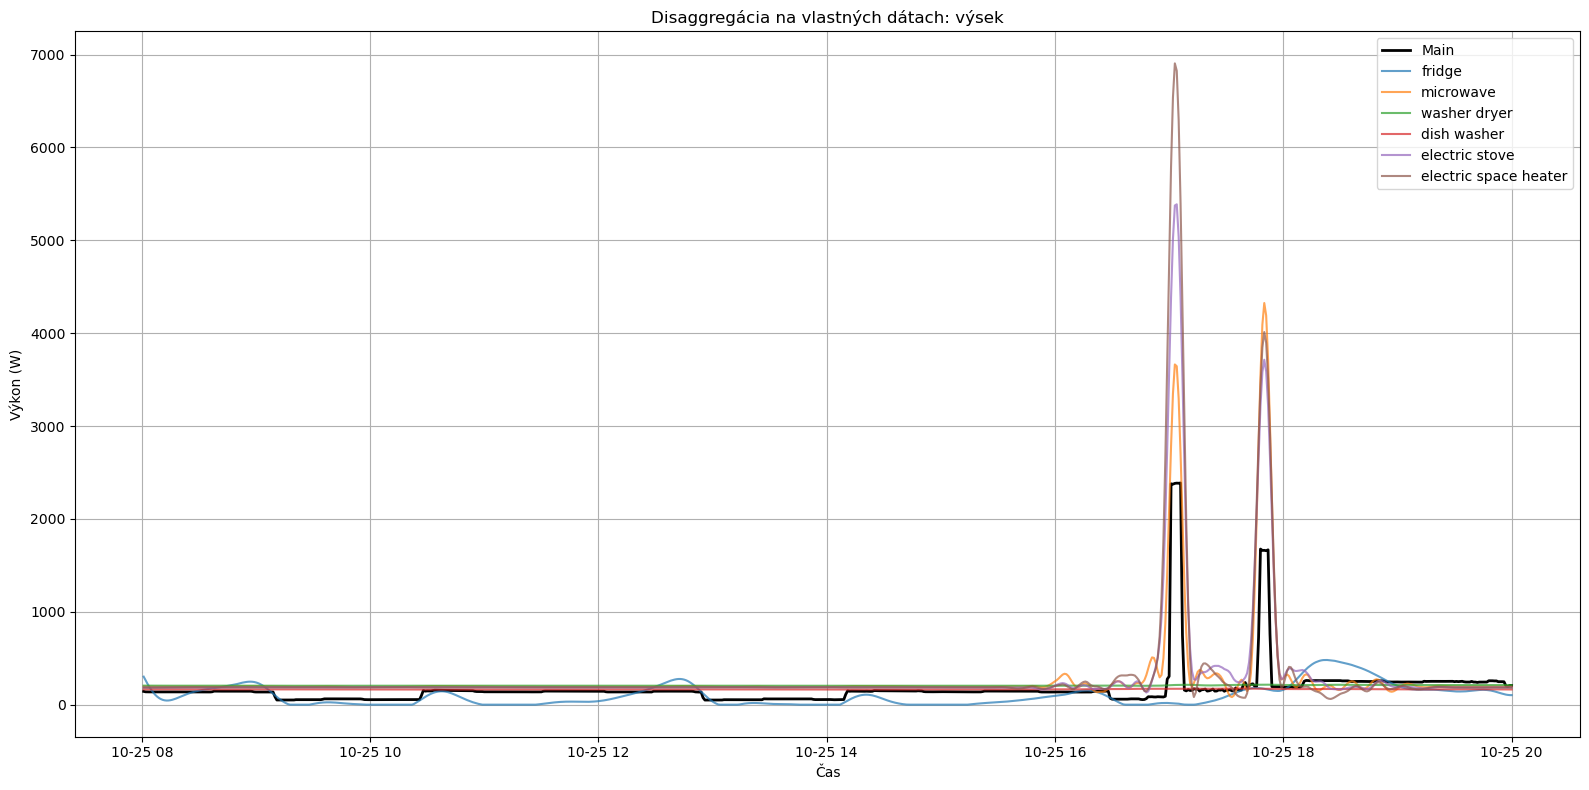

In [110]:
# --- Vizuálne zobrazenie  ---
SAMPLES_PER_HOUR =  1* 60 * 60 // 5
start = 0
end = start + SAMPLES_PER_HOUR

plt.figure(figsize=(16, 8))
plt.plot(df['timestamp'].iloc[start:end], df['main'].iloc[start:end], label="Main", color="black", linewidth=2)   
for appliance, pred in predictions_dict.items():
    plt.plot(df['timestamp'].iloc[start:end], pred[start:end], label=appliance, alpha=0.7)

plt.title("Disaggregácia na vlastných dátach: výsek")
plt.xlabel("Čas")
plt.ylabel("Výkon (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [107]:
from sklearn.metrics import mean_absolute_error, mean_squared_error    
import numpy as np

# Počet vzoriek v jednom okne
SEQUENCE_LENGTH = 99
PRED_SHIFT = SEQUENCE_LENGTH // 2  # Posun do stredu okna

# Zarovnaj predikcie s pôvodným signálom
aligned_pred = pred_final[PRED_SHIFT:len(main_power)]
aligned_main = main_power[:len(aligned_pred)]

# Výpočet metrík
mae = mean_absolute_error(aligned_main, aligned_pred)
mse = mean_squared_error(aligned_main, aligned_pred)
rmse = np.sqrt(mse)

# Výstup
print(f"📊 Výsledky disaggregácie :")
print(f"MAE:  {mae:.2f} W")
print(f"MSE:  {mse:.2f} W²")
print(f"RMSE: {rmse:.2f} W")

📊 Výsledky disaggregácie :
MAE:  158.16 W
MSE:  152312.41 W²
RMSE: 390.27 W
